**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

#### The Dataset that I chose is **BMW Global Sales & Market Data** found here ---> https://www.kaggle.com/datasets/payaldhokane/bmw-global-sales-and-market-data 

## Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("bmw_global_sales_dataset.csv")
df.head()

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


## Dataset Overview

In [2]:
print(df.shape)
df.info()
print("Missing values:\n", df.isnull().sum())
print("Unique value counts per column:")
print(df.nunique())

(1000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   str    
 3   model                  1000 non-null   str    
 4   segment                1000 non-null   str    
 5   engine_type            1000 non-null   str    
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), str(4)
memory usage: 109.5 KB
Mi

In [3]:
df.describe()

,year,month,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000
mean,2019.448000,6.487000,76535.747000,279492.230000,200.230000,9.700000e-01,6.290000e+00,1.200000e+00,5.572000,633.192000
std,2.912005,3.510863,25360.933749,127010.559722,113.096127,2.221557e-16,1.777246e-15,4.443114e-16,2.944059,263.346628
min,2015.000000,1.000000,35060.000000,50363.000000,10.000000,9.700000e-01,6.290000e+00,1.200000e+00,1.000000,15.000000
25%,2017.000000,3.000000,54578.750000,173552.250000,101.750000,9.700000e-01,6.290000e+00,1.200000e+00,3.000000,432.750000
50%,2019.000000,7.000000,75726.000000,278733.500000,197.000000,9.700000e-01,6.290000e+00,1.200000e+00,6.000000,630.000000
75%,2022.000000,10.000000,98730.250000,390110.000000,297.000000,9.700000e-01,6.290000e+00,1.200000e+00,8.000000,842.500000
max,2024.000000,12.000000,119817.000000,498927.000000,399.000000,9.700000e-01,6.290000e+00,1.200000e+00,10.000000,1242.000000


### Target Variable: `units_sold`

First look at the distribution of what we're trying to predict.

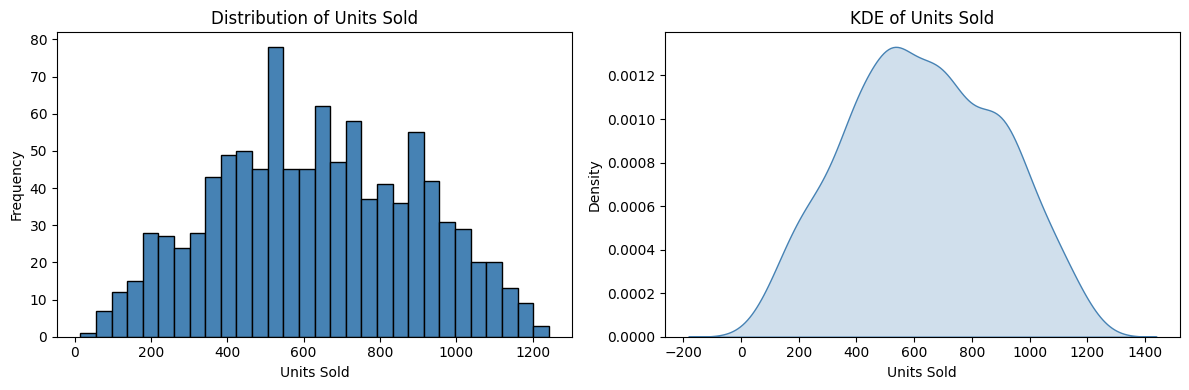

count    1000.000000
mean      633.192000
std       263.346628
min        15.000000
25%       432.750000
50%       630.000000
75%       842.500000
max      1242.000000
Name: units_sold, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['units_sold'], bins=30, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution of Units Sold')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')

sns.kdeplot(df['units_sold'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('KDE of Units Sold')
axes[1].set_xlabel('Units Sold')

plt.tight_layout()
plt.show()

print(df['units_sold'].describe())

### Numeric Features vs. `units_sold`

Key numeric predictors: `price_usd`, `marketing_spend_usd`, `dealership_count`, `competition_index`.


In [5]:
numeric_cols = df.select_dtypes(include='number').columns
print("Standard deviations:")
print(df[numeric_cols].std().round(4))

Standard deviations:
year                          2.9120
month                         3.5109
price_usd                 25360.9337
marketing_spend_usd      127010.5597
dealership_count            113.0961
fuel_price_usd                0.0000
gdp_growth_percent            0.0000
interest_rate_percent         0.0000
competition_index             2.9441
units_sold                  263.3466
dtype: float64


### Categorical Features vs. `units_sold`

Average units sold by `country`, `model`, `engine_type`, and `segment`.

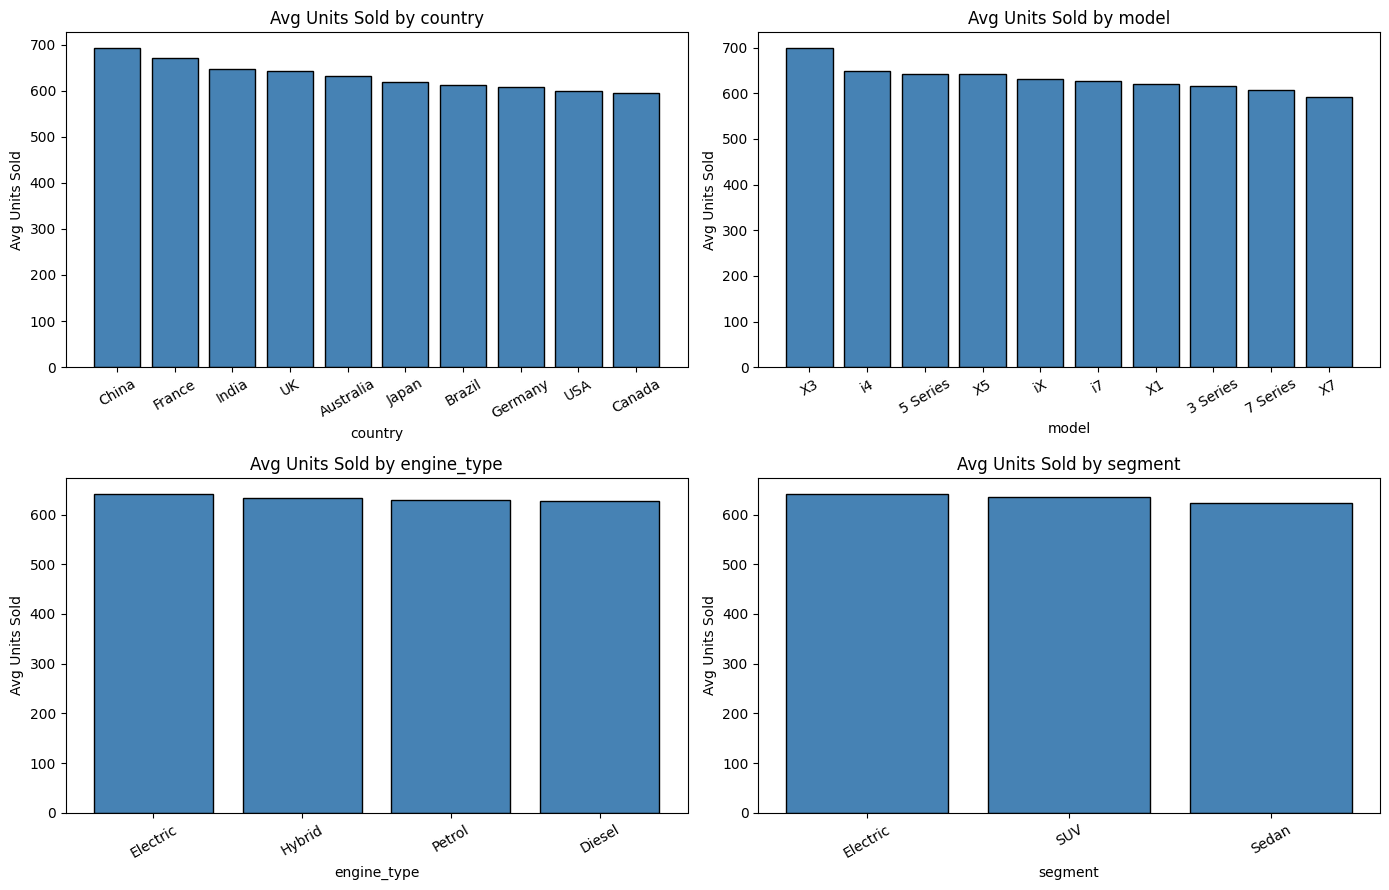

In [6]:
cat_features = ['country', 'model', 'engine_type', 'segment']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, cat in enumerate(cat_features):
    means = df.groupby(cat)['units_sold'].mean().sort_values(ascending=False)
    axes[i].bar(means.index, means.values, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Avg Units Sold by {cat}')
    axes[i].set_xlabel(cat)
    axes[i].set_ylabel('Avg Units Sold')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### KDE of `units_sold` by Categorical Feature

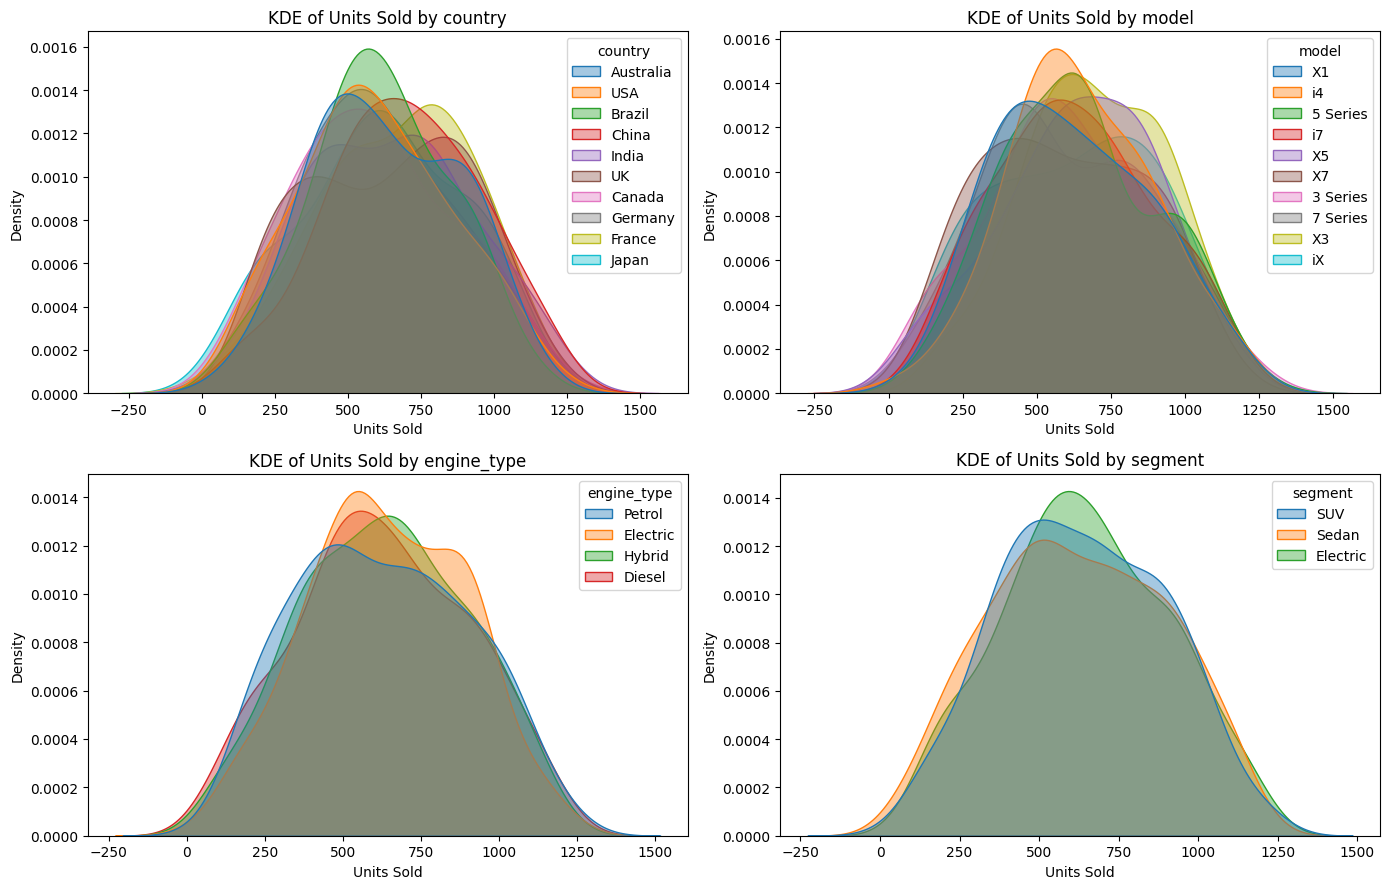

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, cat in enumerate(cat_features):
    sns.kdeplot(data=df, x='units_sold', hue=cat, fill=True, common_norm=False, alpha=0.4, ax=axes[i])
    axes[i].set_title(f'KDE of Units Sold by {cat}')
    axes[i].set_xlabel('Units Sold')

plt.tight_layout()
plt.show()

## EDA Summary

| Feature | Type | Notes |
|---|---|---|
| `marketing_spend_usd` | Numeric | Could be a very strong numeric predictor — more spend -> more sales |
| `dealership_count` | Numeric | More dealerships -> more access -> more sales |
| `price_usd` | Numeric | Expect negative relationship (higher price -> fewer units) |
| `competition_index` | Numeric but I will turn categorical | More competition may suppress sales |
| `country` | Categorical | Market size differs significantly by country |
| `model` | Categorical | Different models have different demand profiles |
| `engine_type` | Categorical | Consumer preference varies (Electric vs Petrol vs Diesel) |
| `segment` | Categorical | SUV vs Sedan etc. affects sales volume |
| `fuel_price_usd`, `gdp_growth_percent`, `interest_rate_percent` | Numeric | These are constant rows so we can drop these. |

### Split the sample into an ~80% training set and a ~20% test set.
### 4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.

First Ill make a model with Numeric Columns alone

In [8]:
x = ['marketing_spend_usd','dealership_count','price_usd']
X_simple = df[x].astype(float)
y_target = df["units_sold"]

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_target, test_size=0.2, random_state=42)

# fit the linear regression model with an intercept for training data 
model = LinearRegression(fit_intercept=True).fit(X_train, y_train)   

# make predictions on the test set
y_pred = model.predict(X_test)

# model evaluation 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print('The Root Mean Squared Error Test set is:', rmse)
print('The R-squared value for Test set is: ', r2)

The Root Mean Squared Error Test set is: 127.7337719516829
The R-squared value for Test set is:  0.761307346644104


Now Ill make a model that uses categorical variables only. 

In [9]:
# create dummy variables for the categorical variables that I want to include and drop the first category to avoid multicollinearity
df2 = pd.get_dummies(df, columns=["country","model","engine_type","segment","competition_index"], drop_first=True, prefix=["Country","Model","Engine_Type","Segment","Competition_Index"])

# Dynamically select all dummy variable columns
Country_cols = [col for col in df2.columns if col.startswith("Country_")]
Model_cols = [col for col in df2.columns if col.startswith("Model_")]
Engine_Type_cols = [col for col in df2.columns if col.startswith("Engine_Type_")]
Segment_cols = [col for col in df2.columns if col.startswith("Segment_")]
Competition_Index_cols = [col for col in df2.columns if col.startswith("Competition_Index_")]

x = Country_cols + Model_cols + Engine_Type_cols + Segment_cols + Competition_Index_cols
X_simple = df2[x].astype(float)  # sklearn expects 2D array for features      
y_target = df2["units_sold"]

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_target, test_size=0.2, random_state=42)

# fit the linear regression model with an intercept for training data 
model = LinearRegression(fit_intercept=True).fit(X_train, y_train)   

# make predictions on the test set
y_pred = model.predict(X_test)

# model evaluation 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print('The Root Mean Squared Error Test set is:', rmse)
print('The R-squared value for Test set is: ', r2)

The Root Mean Squared Error Test set is: 268.0253757223959
The R-squared value for Test set is:  -0.050943588898836545


This indicates a very poor fit for out R2 to be negative. 

Now I'll build a model that uses both categorical and numerical features. 

In [10]:
df3 = pd.get_dummies(df, columns=["country","model","engine_type","segment","competition_index"], drop_first=True, prefix=["Country","Model","Engine_Type","Segment","Competition_Index"])

# Dynamically select all dummy variable columns
Country_cols = [col for col in df3.columns if col.startswith("Country_")]
Model_cols = [col for col in df3.columns if col.startswith("Model_")]
Engine_Type_cols = [col for col in df3.columns if col.startswith("Engine_Type_")]
Segment_cols = [col for col in df3.columns if col.startswith("Segment_")]
Competition_Index_cols = [col for col in df3.columns if col.startswith("Competition_Index_")]

numeric_cols = ['marketing_spend_usd','dealership_count','price_usd']

x = numeric_cols + Country_cols + Model_cols + Engine_Type_cols + Segment_cols + Competition_Index_cols
X_simple = df3[x].astype(float)  # sklearn expects 2D array for features      
y_target = df3["units_sold"]

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_target, test_size=0.2, random_state=42)

# fit the linear regression model with an intercept for training data 
model = LinearRegression(fit_intercept=True).fit(X_train, y_train)   

# make predictions on the test set
y_pred = model.predict(X_test)

# model evaluation 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print('The Root Mean Squared Error Test set is:', rmse)
print('The R-squared value for Test set is: ', r2)

The Root Mean Squared Error Test set is: 131.71678777068564
The R-squared value for Test set is:  0.7461893508063671


**The model using only numerical predictors gave the strongest test performance, with RMSE = 127.73 and R2 = 0.761. When categorical dummy variables were added, test RMSE increased to 131.72 and R2 decreased to 0.746, indicating weaker generalization. This suggests that, for this dataset, the core numeric variables (marketing spend, dealership count, and price) capture most of the predictive signal for units sold. The added categorical features likely introduced extra complexity and noise without providing enough additional predictive value.**


Maybe we can try to add Polynomial regression! 

In [12]:
df4 = pd.get_dummies(df, columns=["country","model","engine_type","segment","competition_index"], drop_first=True, prefix=["Country","Model","Engine_Type","Segment","Competition_Index"])

# Dynamically select all dummy variable columns
Country_cols = [col for col in df4.columns if col.startswith("Country_")]
Model_cols = [col for col in df4.columns if col.startswith("Model_")]
Engine_Type_cols = [col for col in df4.columns if col.startswith("Engine_Type_")]
Segment_cols = [col for col in df4.columns if col.startswith("Segment_")]
Competition_Index_cols = [col for col in df4.columns if col.startswith("Competition_Index_")]

num_col = ['marketing_spend_usd','dealership_count','price_usd']
cat_cols = Country_cols + Model_cols + Engine_Type_cols + Segment_cols + Competition_Index_cols   
y_target = df4["units_sold"]



# Train/test split BEFORE polynomial fit (prevents leakage)
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df4[cat_cols + num_col], y_target, test_size=0.2, random_state=42
)

# Keep categorical dummies as-is
X_train_cat = X_train_df[cat_cols].astype(float).values
X_test_cat = X_test_df[cat_cols].astype(float).values

# Loop over degrees
results = []

for degree in range(1, 23):
    pf = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_num_poly = pf.fit_transform(X_train_df[num_col])
    X_test_num_poly = pf.transform(X_test_df[num_col])

    X_train_final = np.hstack([X_train_cat, X_train_num_poly])
    X_test_final = np.hstack([X_test_cat, X_test_num_poly])

    model = LinearRegression(fit_intercept=True).fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Degree": degree, "RMSE": round(rmse, 4), "R2": round(r2, 4)})

# Print results as a table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Degree     RMSE     R2
      1 131.7168 0.7462
      2 133.1497 0.7406
      3 130.2263 0.7519
      4 129.2906 0.7555
      5 134.4363 0.7356
      6 143.3900 0.6992
      7 156.4912 0.6417
      8 173.4299 0.5600
      9 182.0165 0.5153
     10 189.8635 0.4726
     11 198.1950 0.4253
     12 205.7658 0.3806
     13 211.4766 0.3457
     14 216.7096 0.3130
     15 221.8446 0.2800
     16 228.1267 0.2387
     17 231.8134 0.2139
     18 234.1582 0.1979
     19 236.6303 0.1808
     20 242.3985 0.1404
     21 245.1484 0.1208
     22 247.4908 0.1039


The polynomial regression experiment showed that adding modest nonlinearity helped only a little at first, with the best result at degree 4 (RMSE = 129.29, R2 = 0.756). However, this still did not outperform the numerical-only linear model (RMSE = 127.73, R2 = 0.761). As degree increased beyond 4, test performance worsened, indicating overfitting. Overall, the simplest numerical linear model generalized best on unseen data.



### 5. Which model performed the best, and why?

The best-performing model was the linear regression using only numerical predictors. The reason why is because it had the lowest test RMSE (127.73), meaning the smallest prediction error on unseen data. It had the highest test R2 of 0.761, meaning it explained the most variation in units sold. Also adding the categorical dummy variables and higher-degree polynomial terms increased the model complexity but didn't improve the test performance, which suggests noise rather then additional useful information. 

### 6. What did you learn?

For this dataset specifically I learned that simpler models can generalize better than more complex ones. In this project, the linear regression model with only numerical predictors performed best on the test set (lowest RMSE and highest R2), while adding many categorical dummy variables or high-degree polynomial terms did not improve performance and often made it worse. However, this may indicate that one predictor carries most of the useful signal, while the additional variables add noise and reduce out-of-sample performance. Overall, this project project shows that better generalization comes from choosing features with real predictive signal, not just adding more variables. 